In [47]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Paths
DATA_PATH = Path('../data/processed/2025_Hungary.parquet')
RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('../figures')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Environment check
print(f"PyMC version:  {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"NumPy version: {np.__version__}")


PyMC version:  6.0.0
ArviZ version: 1.1.0
NumPy version: 2.3.3


Loaded 1368 total laps from 2025_Hungary.parquet
Clean laps for modeling: 1289

Model dimensions:
  Drivers:      20
  Constructors: 10
  Compounds:    3
  Observations: 1289

Response variable (lap_time_fuel_corrected):
  Mean:  80.616s
  Std:   0.983s
  Min:   78.155s
  Max:   85.164s


/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


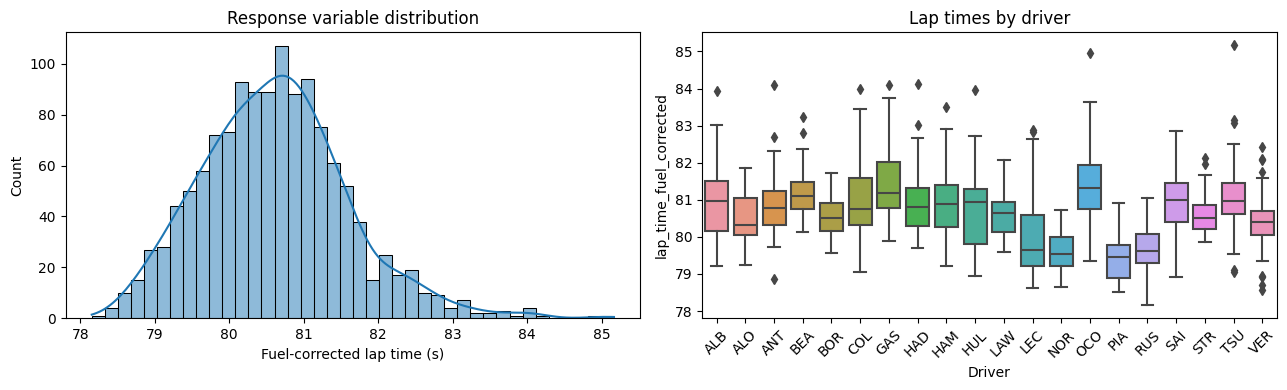

In [48]:
# Load canonical preprocessed dataset
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df)} total laps from {DATA_PATH.name}")

# Filter to clean laps only
df = df[df['anomaly_flag'] == 'normal'].copy().reset_index(drop=True)
print(f"Clean laps for modeling: {len(df)}")

# Build categorical indices for PyMC
# IMPORTANT: build these AFTER all filtering to avoid index misalignment
driver_cat = pd.Categorical(df['Driver'])
constructor_cat = pd.Categorical(df['Team'])
compound_cat = pd.Categorical(df['Compound'])

df['driver_idx'] = driver_cat.codes
df['constructor_idx'] = constructor_cat.codes
df['compound_idx'] = compound_cat.codes

# Preserve category names for posterior interpretation
driver_names = driver_cat.categories.values
constructor_names = constructor_cat.categories.values
compound_names = compound_cat.categories.values

# Center lap_in_stint to decorrelate linear and quadratic tyre terms
df['lap_in_stint_c'] = df['lap_in_stint'] - df['lap_in_stint'].mean()

# Extract model arrays
driver_idx = df['driver_idx'].values
constructor_idx = df['constructor_idx'].values
compound_idx = df['compound_idx'].values
lap_in_stint_c = df['lap_in_stint_c'].values.astype(float)
y = df['lap_time_fuel_corrected'].values

# Counts
n_drivers = len(driver_names)
n_constructors = len(constructor_names)
n_compounds = len(compound_names)

# Summary
print(f"\nModel dimensions:")
print(f"  Drivers:      {n_drivers}")
print(f"  Constructors: {n_constructors}")
print(f"  Compounds:    {n_compounds}")
print(f"  Observations: {len(y)}")

print(f"\nResponse variable (lap_time_fuel_corrected):")
print(f"  Mean:  {y.mean():.3f}s")
print(f"  Std:   {y.std():.3f}s")
print(f"  Min:   {y.min():.3f}s")
print(f"  Max:   {y.max():.3f}s")

# Quick visual sanity check
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(y, bins=40, ax=axes[0], kde=True)
axes[0].set_xlabel('Fuel-corrected lap time (s)')
axes[0].set_title('Response variable distribution')

sns.boxplot(data=df, x='Driver', y='lap_time_fuel_corrected',
            order=driver_names, ax=axes[1])
axes[1].set_title('Lap times by driver')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '00_data_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


In [49]:
with pm.Model() as model:

    # ---- Hyperpriors for random-effect scales ----
    sigma_driver = pm.HalfNormal('sigma_driver', sigma=1.0)
    sigma_constructor = pm.HalfNormal('sigma_constructor', sigma=1.0)

    # ZeroSumNormal enforces sum-to-zero so the random effects are identified
    # against mu_0 (otherwise any constant can be moved between mu_0 and the
    # effect means without changing the likelihood). It has an efficient
    # built-in non-centered parameterization, so no separate _raw layer.
    alpha_d = pm.ZeroSumNormal('alpha_d', sigma=sigma_driver, shape=n_drivers)
    beta_c  = pm.ZeroSumNormal('beta_c',  sigma=sigma_constructor, shape=n_constructors)

    # Compound baseline ("freshness"). Without this, fresh SOFT and fresh MEDIUM
    # are forced to identical pace and the wear slope has to absorb the
    # compound delta. Zero-sum identifies it against mu_0.
    tyre_intercept = pm.ZeroSumNormal('tyre_intercept', sigma=0.5, shape=n_compounds)

    # Compound-specific tyre wear (linear + quadratic)
    tyre_linear = pm.Normal('tyre_linear', mu=0, sigma=0.1,  shape=n_compounds)
    tyre_quad   = pm.Normal('tyre_quad',   mu=0, sigma=0.01, shape=n_compounds)

    # Global intercept (field-average fuel-corrected lap time)
    mu_0 = pm.Normal('mu_0', mu=float(y.mean()), sigma=5.0)

    # Expected lap time
    mu = (
        mu_0
        + alpha_d[driver_idx]
        + beta_c[constructor_idx]
        + tyre_intercept[compound_idx]
        + tyre_linear[compound_idx] * lap_in_stint_c
        + tyre_quad[compound_idx]   * lap_in_stint_c**2
    )

    sigma = pm.HalfNormal('sigma', sigma=1.0)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

print("Model specified.")
print(f"\nFree parameters (after zero-sum constraints):")
print(f"  Driver effects:      {n_drivers - 1} (zero-sum across {n_drivers} levels)")
print(f"  Constructor effects: {n_constructors - 1} (zero-sum across {n_constructors} levels)")
print(f"  Tyre intercept:      {n_compounds - 1} (zero-sum across {n_compounds} levels)")
print(f"  Tyre linear:         {n_compounds}")
print(f"  Tyre quadratic:      {n_compounds}")
print(f"  Hyperpriors:         3 (sigma_driver, sigma_constructor, sigma)")
print(f"  Global intercept:    1")
total_free = (n_drivers - 1) + (n_constructors - 1) + (n_compounds - 1) + 2 * n_compounds + 4
print(f"  Total free:          {total_free}")


Model specified.

Free parameters (after zero-sum constraints):
  Driver effects:      19 (zero-sum across 20 levels)
  Constructor effects: 9 (zero-sum across 10 levels)
  Tyre intercept:      2 (zero-sum across 3 levels)
  Tyre linear:         3
  Tyre quadratic:      3
  Hyperpriors:         3 (sigma_driver, sigma_constructor, sigma)
  Global intercept:    1
  Total free:          40


In [50]:
with model:
    trace = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        progressbar=True
    )

# Save trace immediately so we don't lose it
trace.to_netcdf(RESULTS_DIR / 'hungary_2025_baseline_trace.nc')

# Quick post-sampling check
n_divergences = int(trace.sample_stats['diverging'].sum())
total_draws = int(trace.posterior.sizes['chain'] * trace.posterior.sizes['draw'])
print(f"\nSampling complete.")
print(f"Total draws:  {total_draws}")
print(f"Divergences:  {n_divergences} ({100*n_divergences/total_draws:.2f}%)")

if n_divergences > 0.01 * total_draws:
    print("WARNING: >1% divergences. Consider higher target_accept or model respec.")
else:
    print("Divergence rate acceptable.")


Initializing NUTS using jitter+adapt_diag...
<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Vector(float64, shape=(20,))) must be compatible with the type of the original Variable (Vector(float64, shape=(10,))). inline_ofg_expansion
Rewrite failure due to: inline_ofg_expansion
node: ZeroSumNormal{inline=True}(RNG(<Generator(PCG64) at 0x16E370660>), [], ExpandDims{axis=0}.0, ExpandDims{axis=0}.0)
TRACEBACK:
Traceback (most recent call last):
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/rewriting/basic.py", line 1968, in process_node
    fgraph.replace_all_validate_remove(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        repl_pairs, reason=node_rewriter, remove=remove
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/features.py", line 842, in replace_all_validate_remove
    chk = fgraph.replace_all_val

KeyboardInterrupt: 

In [ ]:
# ---- Convergence diagnostics ----
summary = az.summary(
    trace,
    var_names=['alpha_d', 'beta_c', 'tyre_intercept', 'tyre_linear', 'tyre_quad',
               'sigma_driver', 'sigma_constructor', 'sigma', 'mu_0'],
    ci_prob=0.95
)

# ArviZ 1.x az.summary() returns formatted strings; coerce numeric cols for arithmetic.
summary_num = summary.apply(pd.to_numeric, errors='coerce')

max_rhat = float(summary_num['r_hat'].max())
min_ess_bulk = float(summary_num['ess_bulk'].min())
min_ess_tail = float(summary_num['ess_tail'].min())

print("=" * 60)
print("CONVERGENCE DIAGNOSTICS")
print("=" * 60)
print(f"Max R-hat:    {max_rhat:.4f}  (target: < 1.01)")
print(f"Min ESS bulk: {min_ess_bulk:.0f}    (target: > 400)")
print(f"Min ESS tail: {min_ess_tail:.0f}    (target: > 400)")

problems = summary_num[(summary_num['r_hat'] > 1.01) | (summary_num['ess_bulk'] < 400)]
if len(problems) > 0:
    print(f"\n{len(problems)} parameters with convergence issues:")
    print(problems[['mean', 'sd', 'r_hat', 'ess_bulk']])
else:
    print("\nAll parameters pass convergence checks.")

# ---- Driver rankings ----
print("\n" + "=" * 60)
print("DRIVER EFFECTS (negative = faster than field average)")
print("=" * 60)

driver_means = trace.posterior['alpha_d'].mean(dim=['chain', 'draw']).values
driver_hdi   = az.hdi(trace, var_names=['alpha_d'], prob=0.95)['alpha_d'].values

driver_results = pd.DataFrame({
    'driver': driver_names,
    'effect': driver_means,
    'hdi_low': driver_hdi[:, 0],
    'hdi_high': driver_hdi[:, 1]
}).sort_values('effect').reset_index(drop=True)

for _, row in driver_results.iterrows():
    print(f"  {row['driver']:5s}  {row['effect']:+.3f}s  "
          f"[95% HDI: {row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]")

# ---- Constructor rankings ----
print("\n" + "=" * 60)
print("CONSTRUCTOR EFFECTS (negative = faster than field average)")
print("=" * 60)

constructor_means = trace.posterior['beta_c'].mean(dim=['chain', 'draw']).values
constructor_hdi   = az.hdi(trace, var_names=['beta_c'], prob=0.95)['beta_c'].values

constructor_results = pd.DataFrame({
    'constructor': constructor_names,
    'effect': constructor_means,
    'hdi_low': constructor_hdi[:, 0],
    'hdi_high': constructor_hdi[:, 1]
}).sort_values('effect').reset_index(drop=True)

for _, row in constructor_results.iterrows():
    print(f"  {row['constructor']:25s}  {row['effect']:+.3f}s  "
          f"[95% HDI: {row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]")

# ---- Variance decomposition ----
print("\n" + "=" * 60)
print("VARIANCE DECOMPOSITION")
print("=" * 60)

sigma_d = trace.posterior['sigma_driver'].mean().item()
sigma_c = trace.posterior['sigma_constructor'].mean().item()
sigma_r = trace.posterior['sigma'].mean().item()

total_var = sigma_d**2 + sigma_c**2 + sigma_r**2

print(f"  Driver:      sigma = {sigma_d:.3f}s   variance share = {100*sigma_d**2/total_var:5.1f}%")
print(f"  Constructor: sigma = {sigma_c:.3f}s   variance share = {100*sigma_c**2/total_var:5.1f}%")
print(f"  Residual:    sigma = {sigma_r:.3f}s   variance share = {100*sigma_r**2/total_var:5.1f}%")
print(f"  Ratio constructor/driver (std): {sigma_c/sigma_d:.2f}x")

# ---- Tyre baseline + wear coefficients ----
print("\n" + "=" * 60)
print("TYRE BASELINE & WEAR (per compound)")
print("=" * 60)

tyre_int_means  = trace.posterior['tyre_intercept'].mean(dim=['chain', 'draw']).values
tyre_lin_means  = trace.posterior['tyre_linear'].mean(dim=['chain', 'draw']).values
tyre_quad_means = trace.posterior['tyre_quad'].mean(dim=['chain', 'draw']).values

for i, compound in enumerate(compound_names):
    print(f"  {compound:7s}  intercept: {tyre_int_means[i]:+.3f}s   "
          f"linear: {tyre_lin_means[i]:+.4f}s/lap   "
          f"quadratic: {tyre_quad_means[i]:+.5f}s/lap²")

# ---- Save results ----
driver_results.to_csv(RESULTS_DIR / 'hungary_2025_driver_effects.csv', index=False)
constructor_results.to_csv(RESULTS_DIR / 'hungary_2025_constructor_effects.csv', index=False)

from datetime import datetime, timezone

with open(RESULTS_DIR / 'hungary_2025_summary.md', 'w') as f:
    f.write("# Hungary 2025 Foundational Regression - Baseline Results\n\n")

    # Provenance: lineage so a saved summary is interpretable later.
    f.write("## Provenance\n")
    f.write(f"- Generated:    {datetime.now(timezone.utc).isoformat(timespec='seconds')}\n")
    f.write(f"- Random seed:  {RANDOM_SEED}\n")
    f.write(f"- Observations: {len(y)} clean laps\n")
    f.write(f"- PyMC:         {pm.__version__}\n")
    f.write(f"- ArviZ:        {az.__version__}\n\n")

    f.write("## Convergence\n")
    f.write(f"- Max R-hat: {max_rhat:.4f}\n")
    f.write(f"- Min ESS bulk: {min_ess_bulk:.0f}\n")
    f.write(f"- Divergences: {n_divergences} / {total_draws} ({100*n_divergences/total_draws:.2f}%)\n\n")

    f.write("## Variance Decomposition\n")
    f.write(f"- Driver sigma: {sigma_d:.3f}s ({100*sigma_d**2/total_var:.1f}%)\n")
    f.write(f"- Constructor sigma: {sigma_c:.3f}s ({100*sigma_c**2/total_var:.1f}%)\n")
    f.write(f"- Residual sigma: {sigma_r:.3f}s ({100*sigma_r**2/total_var:.1f}%)\n\n")

    # Tyre intercept = baseline pace at the *mean* stint position by compound
    # (since lap_in_stint was centered). NOT fresh-tyre pace per se.
    f.write("## Tyre Baseline & Wear (per compound)\n")
    f.write("intercept = pace at mean stint position; linear/quadratic = wear coefficients.\n\n")
    for i, compound in enumerate(compound_names):
        f.write(
            f"- {compound}: intercept {tyre_int_means[i]:+.3f}s, "
            f"linear {tyre_lin_means[i]:+.4f}s/lap, "
            f"quadratic {tyre_quad_means[i]:+.5f}s/lap^2\n"
        )
    f.write("\n")

    f.write("## Top 5 Drivers\n")
    for _, row in driver_results.head(5).iterrows():
        f.write(f"- {row['driver']}: {row['effect']:+.3f}s "
                f"[{row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]\n")
    f.write("\n## Top 5 Constructors\n")
    for _, row in constructor_results.head(5).iterrows():
        f.write(f"- {row['constructor']}: {row['effect']:+.3f}s "
                f"[{row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]\n")

print(f"\nResults saved to {RESULTS_DIR}/")


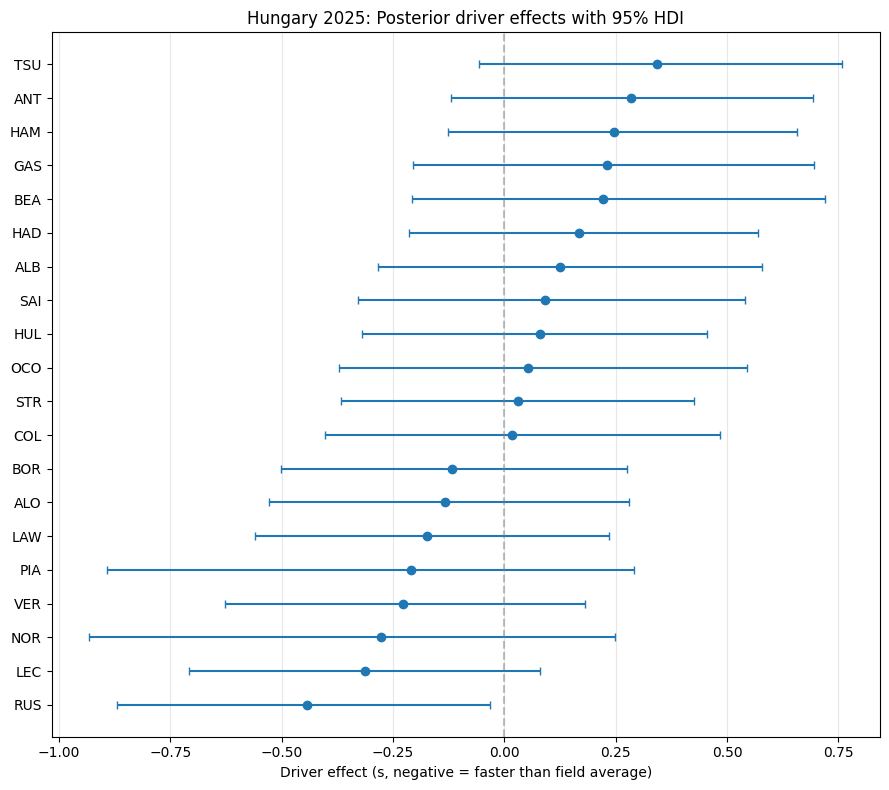

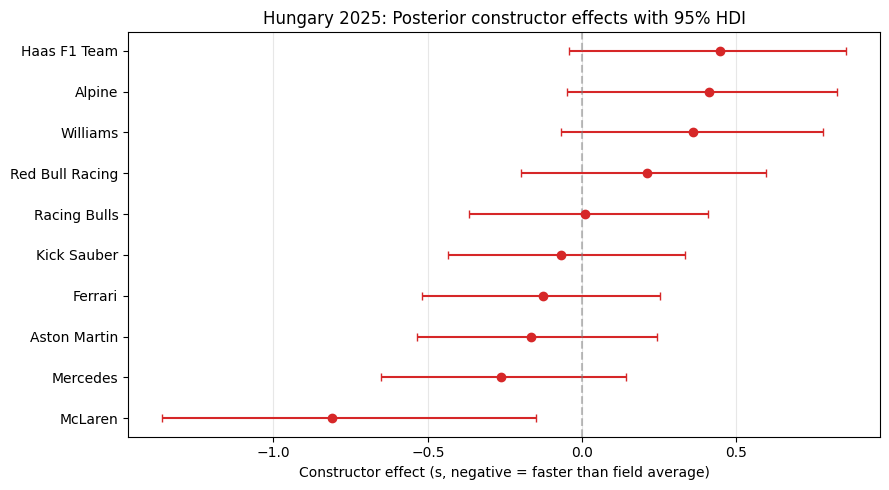

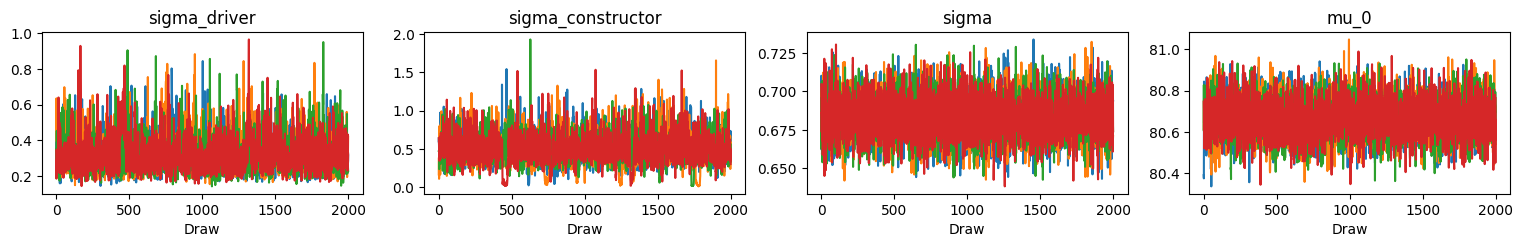

Sampling: [y_obs]


Output()

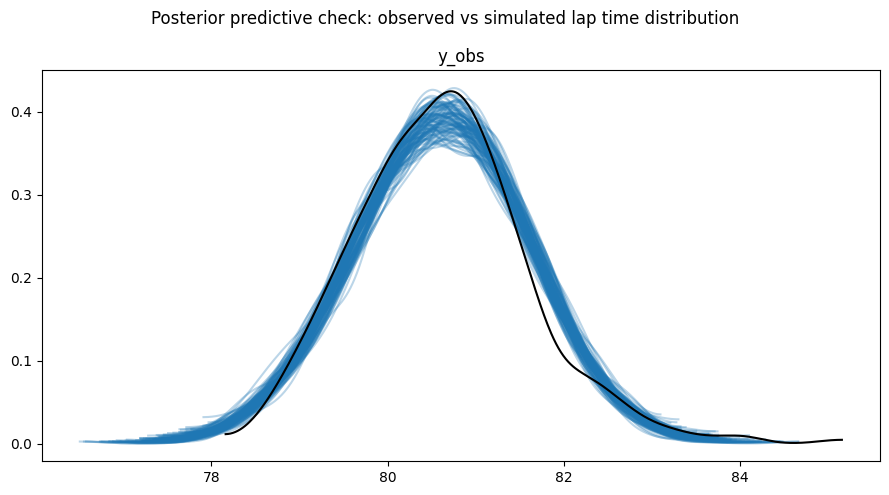

In [ ]:
# ---- Forest plot of driver effects ----
fig, ax = plt.subplots(figsize=(9, 8))
sorted_drivers = driver_results.sort_values('effect', ascending=True)
positions = np.arange(len(sorted_drivers))

ax.errorbar(
    sorted_drivers['effect'],
    positions,
    xerr=[sorted_drivers['effect'] - sorted_drivers['hdi_low'],
          sorted_drivers['hdi_high'] - sorted_drivers['effect']],
    fmt='o', markersize=6, capsize=3, color='#1f77b4'
)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(positions)
ax.set_yticklabels(sorted_drivers['driver'])
ax.set_xlabel('Driver effect (s, negative = faster than field average)')
ax.set_title('Hungary 2025: Posterior driver effects with 95% HDI')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_hungary_driver_effects.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Forest plot of constructor effects ----
fig, ax = plt.subplots(figsize=(9, 5))
sorted_constructors = constructor_results.sort_values('effect', ascending=True)
positions = np.arange(len(sorted_constructors))

ax.errorbar(
    sorted_constructors['effect'],
    positions,
    xerr=[sorted_constructors['effect'] - sorted_constructors['hdi_low'],
          sorted_constructors['hdi_high'] - sorted_constructors['effect']],
    fmt='o', markersize=6, capsize=3, color='#d62728'
)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(positions)
ax.set_yticklabels(sorted_constructors['constructor'])
ax.set_xlabel('Constructor effect (s, negative = faster than field average)')
ax.set_title('Hungary 2025: Posterior constructor effects with 95% HDI')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_hungary_constructor_effects.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Trace plots for sanity checking convergence ----
az.plot_trace(trace, var_names=['sigma_driver', 'sigma_constructor', 'sigma', 'mu_0'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_hungary_hyperparameter_traces.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- Posterior predictive check ----
# Extend `trace` in-place with the posterior_predictive group so
# plot_ppc_dist (ArviZ 1.x) can pair it with observed_data on the same DataTree.
with model:
    pm.sample_posterior_predictive(
        trace,
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
    )

# ArviZ 1.x: plot_ppc -> plot_ppc_dist. No ax/alpha/color kwargs; styling via `visuals`.
az.plot_ppc_dist(trace, num_samples=100)
plt.gcf().set_size_inches(9, 5)
plt.suptitle('Posterior predictive check: observed vs simulated lap time distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_hungary_posterior_predictive.png', dpi=120, bbox_inches='tight')
plt.show()
